# CC-KAN — A Self-Explaining, Clinically-Constrained Model for Heart Disease Prediction
### A beginner-friendly, runnable walkthrough

**What this notebook builds, in one paragraph.**
Most machine-learning models that predict heart disease are *black boxes*: they give an answer but cannot tell you *why*, which makes doctors reluctant to trust them. The usual patch is to run an "explainer" tool (SHAP/LIME) *after* training that only *guesses* the model's reasoning. We take a cleaner route. We build a model that **explains itself by design** and is **forced to reason in ways a cardiologist would agree with** — for example, "a higher maximum heart rate should never *increase* predicted risk." We then test, honestly, whether making the model obey these medical rules costs any accuracy. (Spoiler, supported by the experiments below: it doesn't.)

**The three ideas you need (each explained again where it's used):**
1. **KAN (Kolmogorov–Arnold Network).** A normal neural network multiplies each input by a fixed number (a straight-line effect). A KAN instead learns a whole *curve* for each input — a flexible shape. A curve is something you can literally look at, so it is more interpretable.
2. **Additive model (self-explaining).** We add up one curve per feature: `risk = curve(age) + curve(cholesterol) + …`. Because it is a plain sum, each curve *is exactly* that feature's contribution — like an **itemized receipt** instead of a single lump-sum total. No after-the-fact guessing needed.
3. **Clinical monotonicity constraint.** We force each known risk factor's curve to move in the medically-correct direction (always up, or always down). Two ways: a **soft** version (a fine that grows the more the rule is broken) and a **hard** version (the curve is *built* from one-way "ratchet" pieces so it *cannot* reverse).

**Workflow of this notebook:** download data → define models → clean data without cheating → compare models fairly → study the effect of the constraint → visualize the explanations → sanity-check against a famous prior result → analyze thresholds → test on a *different* hospital → ablation. Just press **Runtime → Run all**. At the end, copy the block under `=== RESULTS TO SEND BACK ===`.


## 1. Setup and data download
**What happens here.** Like gathering ingredients before cooking, we install a few libraries and download the two datasets we use: the **Cleveland** and **Hungarian** cohorts of the classic UCI *Heart Disease* collection. Each row is one patient described by 13 measurements (age, sex, chest-pain type, resting blood pressure, cholesterol, max heart rate, ST-depression, etc.), plus a label: heart disease present (1) or not (0).

*No files to upload* — the cells fetch everything from public mirrors of the original UCI data. We also grab a larger 918-row "merged" dataset that we only use much later (Experiment D) to double-check a claim from a prior paper.


In [1]:
!pip install -q xgboost imbalanced-learn 2>/dev/null
import warnings, os, json, time, math, requests
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import RobustScaler, QuantileTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, recall_score,
                             balanced_accuracy_score)
from scipy.stats import wilcoxon
import xgboost as xgb
SEED=42; np.random.seed(SEED); torch.manual_seed(SEED); torch.set_num_threads(2)
print("torch", torch.__version__)


torch 2.11.0+cu128


In [2]:
os.makedirs("data", exist_ok=True)
SOURCES = {
 "cleveland":   "https://raw.githubusercontent.com/reinaldoq/processing-heart-disease-dataset/master/processed.cleveland.data",
 "hungarian":   "https://raw.githubusercontent.com/nyuvis/datasets/master/heart/processed.hungarian.data",
 "switzerland": "https://raw.githubusercontent.com/nyuvis/datasets/master/heart/processed.switzerland.data",
 "va":          "https://raw.githubusercontent.com/nyuvis/datasets/master/heart/processed.va.data",
 "merged918":   "https://raw.githubusercontent.com/anik199/Heart-failure-prediction/main/heart.csv",
}
for name,url in SOURCES.items():
    r=requests.get(url,timeout=30); open(f"data/{name}.data","wb").write(r.content)
    print(f"{name:11s} {len(r.content):>7d} bytes")


cleveland     18461 bytes
hungarian     10369 bytes
switzerland    4109 bytes
va             6737 bytes
merged918     35921 bytes


## 2. Reading the data into tables
**What happens here.** The raw files are plain text: numbers separated by commas, with a `?` wherever a value is missing. This cell turns that text into clean tables (`DataFrame`s), marks the missing `?` as proper "missing" values, and creates the binary target (`disease` = 1 if the original severity score is above 0).

The printout shows each cohort's size and how many patients are healthy vs. diseased — useful because a model that always guesses "healthy" can look deceptively good if most patients *are* healthy (we account for this later using AUC, not just accuracy).


In [3]:
COLS=["age","sex","cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak","slope","ca","thal","num"]
NUMERIC=["age","trestbps","chol","thalach","oldpeak"]
CATEG=["sex","cp","fbs","restecg","exang","slope","ca","thal"]
def load_uci(name):
    rows=[]
    for line in open(f"data/{name}.data"):
        line=line.strip()
        if not line or line.startswith("(") or line.lower().startswith("age"): continue
        p=line.replace("?","nan").split(",")
        if len(p)>=14: rows.append(p[:14])
    df=pd.DataFrame(rows,columns=COLS).apply(pd.to_numeric,errors="coerce")
    df["target"]=(df["num"]>0).astype(int); return df.drop(columns=["num"])
def drop_high_missing(df,thresh=0.60):
    keep=[c for c in df.columns if c=="target" or df[c].isna().mean()<=thresh]
    return df[keep],[c for c in df.columns if c not in keep]
for n in ["cleveland","hungarian","switzerland","va"]:
    d=load_uci(n); print(f"{n:11s} n={len(d)} disease={int(d.target.sum())} healthy={int((d.target==0).sum())}")


cleveland   n=303 disease=139 healthy=164
hungarian   n=294 disease=106 healthy=188
switzerland n=123 disease=115 healthy=8
va          n=200 disease=149 healthy=51


## 3. The models — from a plain neural net to a self-explaining, rule-obeying KAN
**What happens here.** This is the heart of the notebook. We define three related models, from least to most constrained:

- **Plain KAN** (`KAN`): a standard Kolmogorov–Arnold network. *Analogy:* where a normal neural net has a fixed-ratio knob for each input, a KAN has a **dimmer with a custom-shaped response curve** it learns from data.
- **Soft CC-KAN** (`train_cckan`): an **additive** KAN (one curve per feature, summed) plus a **penalty** that pushes each clinical feature's curve toward its medically-correct direction. *Analogy:* a **parking fine** — you *can* still park illegally, but it costs you, so you usually don't.
- **Hard CC-KAN** (`MonoAdditive` / `train_hardmono`): the same additive idea, but each constrained feature's curve is *built* from non-negative combinations of increasing S-curves, so it is **monotone by construction**. *Analogy:* a **ratchet wrench** — mechanically it can only turn one way; breaking the rule is impossible, not just discouraged.

**Why monotonicity is the right kind of knowledge.** Cardiology already knows the *direction* of many effects: more ST-depression (`oldpeak`) → more risk; a higher achievable maximum heart rate (`thalach`) → *less* risk (a fitter heart). We encode exactly these directions (`CLIN` dictionary: `+1` = raises risk, `−1` = lowers risk).

**The math guarantee (hard version), stated simply.** Each constrained curve is `s · Σ αₖ·sigmoid(ωₖ·x + bₖ)` with `αₖ ≥ 0` and `ωₖ ≥ 0`. A sigmoid is increasing; a non-negative sum of increasing functions is increasing; multiplying by the sign `s` sets the direction. Therefore the curve *cannot* violate the clinical direction — a one-line proof, and the reason the hard model scores a perfect monotonicity check later.

*(You do not need to read every line of code. The key objects are `KAN`, `train_cckan`/`ens_cckan` for the soft model, and `train_hardmono`/`ens_hardmono` for the hard model.)*


In [4]:
class KANLinear(nn.Module):
    def __init__(self,in_f,out_f,grid_size=5,spline_order=3,scale_noise=0.1,scale_base=1.0,
                 scale_spline=1.0,base_activation=nn.SiLU,grid_range=(-1,1)):
        super().__init__()
        self.in_features,self.out_features=in_f,out_f
        self.grid_size,self.spline_order=grid_size,spline_order
        h=(grid_range[1]-grid_range[0])/grid_size
        grid=((torch.arange(-spline_order,grid_size+spline_order+1)*h+grid_range[0]).expand(in_f,-1).contiguous())
        self.register_buffer("grid",grid)
        self.base_weight=nn.Parameter(torch.Tensor(out_f,in_f))
        self.spline_weight=nn.Parameter(torch.Tensor(out_f,in_f,grid_size+spline_order))
        self.scale_base,self.scale_spline,self.scale_noise=scale_base,scale_spline,scale_noise
        self.base_activation=base_activation(); self.reset_parameters()
    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.base_weight,a=math.sqrt(5)*self.scale_base)
        with torch.no_grad():
            noise=(torch.rand(self.grid_size+1,self.in_features,self.out_features)-0.5)*self.scale_noise/self.grid_size
            self.spline_weight.data.copy_(self.scale_spline*self.curve2coeff(self.grid.T[self.spline_order:-self.spline_order],noise))
    def b_splines(self,x):
        grid=self.grid; x=x.unsqueeze(-1)
        bases=((x>=grid[:,:-1])&(x<grid[:,1:])).to(x.dtype)
        for k in range(1,self.spline_order+1):
            bases=((x-grid[:,:-(k+1)])/(grid[:,k:-1]-grid[:,:-(k+1)])*bases[:,:,:-1])+((grid[:,k+1:]-x)/(grid[:,k+1:]-grid[:,1:(-k)])*bases[:,:,1:])
        return bases.contiguous()
    def curve2coeff(self,x,y):
        A=self.b_splines(x).transpose(0,1); B=y.transpose(0,1)
        return torch.linalg.lstsq(A,B).solution.permute(2,0,1).contiguous()
    def forward(self,x):
        base=F.linear(self.base_activation(x),self.base_weight)
        spline=F.linear(self.b_splines(x).view(x.size(0),-1),self.spline_weight.view(self.out_features,-1))
        return base+spline

class KAN(nn.Module):
    def __init__(self,layers,grid_size=5,spline_order=3):
        super().__init__()
        self.layers=nn.ModuleList([KANLinear(a,b,grid_size=grid_size,spline_order=spline_order) for a,b in zip(layers[:-1],layers[1:])])
    def forward(self,x):
        for l in self.layers: x=l(x)
        return x

CLIN={"age":+1,"trestbps":+1,"chol":+1,"thalach":-1,"oldpeak":+1,"exang":+1,"ca":+1}

# ---------- soft CC-KAN (additive spline KAN + monotonicity penalty) ----------
def feature_curve(layer,fidx,xs_col):
    N=xs_col.shape[0]; xs=torch.zeros(N,layer.in_features); xs[:,fidx]=xs_col
    bs=layer.b_splines(xs); w=layer.spline_weight[0,fidx,:]
    return bs[:,fidx,:]@w + layer.base_activation(xs[:,fidx])*layer.base_weight[0,fidx]
def train_cckan(Xtr,ytr,cons,ranges,constrained=True,epochs=220,lam_mono=4.0,lam_l1=1e-3,grid=5):
    m=KAN([Xtr.shape[1],1],grid_size=grid,spline_order=3)
    opt=torch.optim.Adam(m.parameters(),lr=0.02,weight_decay=1e-4); lf=nn.BCEWithLogitsLoss()
    Xt=torch.tensor(Xtr,dtype=torch.float32); yt=torch.tensor(ytr,dtype=torch.float32).view(-1,1)
    grids={f:torch.linspace(ranges[f][0],ranges[f][1],40) for f in cons}
    for _ in range(epochs):
        opt.zero_grad(); loss=lf(m(Xt),yt)+lam_l1*sum(l.spline_weight.abs().mean() for l in m.layers)
        if constrained:
            mp=0.0
            for f,d in cons.items():
                g=feature_curve(m.layers[0],f,grids[f]); mp=mp+torch.relu(-d*(g[1:]-g[:-1])).mean()
            loss=loss+lam_mono*mp
        loss.backward(); opt.step()
    m.eval(); return m
def predict_cckan(m,Xte):
    with torch.no_grad(): return torch.sigmoid(m(torch.tensor(Xte,dtype=torch.float32))).numpy().ravel()
def mono_continuous(m,cons,ranges):
    fr=[]
    for f,d in cons.items():
        xs=torch.linspace(ranges[f][0],ranges[f][1],60)
        with torch.no_grad(): g=feature_curve(m.layers[0],f,xs).numpy()
        fr.append(np.mean((d*np.diff(g))>=-1e-6))
    return float(np.mean(fr))
def ens_cckan(Xtr,ytr,Xte,cons,ranges,constrained,lam_mono=4.0,n=5):
    rng=np.random.default_rng(SEED); probs=[]; monos=[]
    for s in range(n):
        idx=rng.integers(0,len(Xtr),len(Xtr)); torch.manual_seed(SEED+s)
        m=train_cckan(Xtr[idx],ytr[idx],cons,ranges,constrained=constrained,lam_mono=lam_mono)
        probs.append(predict_cckan(m,Xte)); monos.append(mono_continuous(m,cons,ranges))
    return np.mean(probs,axis=0), float(np.mean(monos))

# ---------- HARD-monotone additive model (KAN-style, monotone by construction) ----------
# Each constrained feature: g_j(x)=s_j * sum_k softplus(a_k)*sigmoid(softplus(w_k)*x+b_k)  (guaranteed monotone)
class MonoAdditive(nn.Module):
    def __init__(self,d,cons,n_basis=8):
        super().__init__(); self.d=d; self.cons=cons; self.K=n_basis
        self.a=nn.Parameter(torch.randn(d,n_basis)*0.1)
        self.w=nn.Parameter(torch.randn(d,n_basis)*0.5)
        self.b=nn.Parameter(torch.randn(d,n_basis)*0.5)
        self.bias=nn.Parameter(torch.zeros(1))
    def feature_contrib(self,x,j):
        a,w,b=self.a[j],self.w[j],self.b[j]
        if j in self.cons:
            a=F.softplus(a); w=F.softplus(w)  # a>=0, w>=0 -> monotone increasing
            g=(a*torch.sigmoid(w*x.unsqueeze(1)+b)).sum(1)
            return self.cons[j]*g
        return (a*torch.sigmoid(w*x.unsqueeze(1)+b)).sum(1)
    def forward(self,X):
        out=self.bias.expand(X.shape[0]).clone()
        for j in range(self.d): out=out+self.feature_contrib(X[:,j],j)
        return out.unsqueeze(1)
def train_hardmono(Xtr,ytr,cons,epochs=350,lr=0.02,l1=1e-3):
    m=MonoAdditive(Xtr.shape[1],cons); opt=torch.optim.Adam(m.parameters(),lr=lr); lf=nn.BCEWithLogitsLoss()
    Xt=torch.tensor(Xtr,dtype=torch.float32); yt=torch.tensor(ytr,dtype=torch.float32).view(-1,1)
    for _ in range(epochs):
        opt.zero_grad(); (lf(m(Xt),yt)+l1*F.softplus(m.a).mean()).backward(); opt.step()
    m.eval(); return m
def predict_hardmono(m,Xte):
    with torch.no_grad(): return torch.sigmoid(m(torch.tensor(Xte,dtype=torch.float32))).numpy().ravel()
def ens_hardmono(Xtr,ytr,Xte,cons,n=5,return_train=False):
    rng=np.random.default_rng(SEED); probs=[]; tr=[]
    for s in range(n):
        idx=rng.integers(0,len(Xtr),len(Xtr)); torch.manual_seed(SEED+s)
        m=train_hardmono(Xtr[idx],ytr[idx],cons)
        probs.append(predict_hardmono(m,Xte))
        if return_train: tr.append(predict_hardmono(m,Xtr))
    if return_train: return np.mean(probs,axis=0), np.mean(tr,axis=0)
    return np.mean(probs,axis=0)
def hardmono_check(Xtr,ytr,cons,ranges):
    torch.manual_seed(SEED); m=train_hardmono(Xtr,ytr,cons); good=[]
    for j,sd in cons.items():
        xs=torch.linspace(ranges[j][0],ranges[j][1],60)
        with torch.no_grad(): g=m.feature_contrib(xs,j).numpy()
        good.append(float(np.mean((sd*np.diff(g))>=-1e-9)))
    return float(np.mean(good)), m

# ---------- plain multi-layer KAN ----------
def kan_fit_eval(Xtr,ytr,Xte,width=6,grid=4,order=3,lr=0.02,l1=1e-3,epochs=120):
    order=min(order,grid); m=KAN([Xtr.shape[1],width,1],grid_size=grid,spline_order=order)
    opt=torch.optim.Adam(m.parameters(),lr=lr,weight_decay=1e-4); lf=nn.BCEWithLogitsLoss()
    Xt=torch.tensor(Xtr,dtype=torch.float32); yt=torch.tensor(ytr,dtype=torch.float32).view(-1,1)
    m.train()
    for _ in range(epochs):
        opt.zero_grad(); (lf(m(Xt),yt)+l1*sum(l.spline_weight.abs().mean() for l in m.layers)).backward(); opt.step()
    m.eval()
    with torch.no_grad(): return torch.sigmoid(m(torch.tensor(Xte,dtype=torch.float32))).numpy().ravel()
def ens_kan_improved(Xtr,ytr,Xte,n=6,width=4,grid=3,epochs=150):
    rng=np.random.default_rng(SEED); probs=[]
    for s in range(n):
        idx=rng.integers(0,len(Xtr),len(Xtr)); torch.manual_seed(SEED+s)
        probs.append(kan_fit_eval(Xtr[idx],ytr[idx],Xte,width,grid,3,0.02,1e-3,epochs))
    return np.mean(probs,axis=0)
print("KAN, CC-KAN(soft), CC-KAN-Hard defined.")


KAN, CC-KAN(soft), CC-KAN-Hard defined.


## 4. Cleaning the data — *without cheating* (leak-free preprocessing)
**What happens here.** Real clinical data has missing values, outliers, and features on wildly different scales, so we (1) fill missing values, (2) cap extreme outliers using the interquartile-range rule, (3) rescale features, and (4) map them through a *quantile transform* so their distribution fits the KAN's spline grid.

**The crucial scientific point — no data leakage.** Every one of these steps is *learned from the training patients only* and then applied to the held-out test patients. *Analogy:* it's like **studying for an exam without seeing the actual exam questions in advance.** If you fit the scaler (or imputation, or anything) using the test patients too, the model effectively "peeks," and the reported score becomes dishonestly high. Many published heart-disease results are inflated for exactly this reason; we avoid it deliberately. This is why our headline numbers may look lower than some papers' — they are *honest*.


In [5]:
def base_clean(train_df,test_df,feat):
    num=[c for c in NUMERIC if c in feat]; cat=[c for c in CATEG if c in feat]
    Xtr,Xte=train_df[feat].copy(),test_df[feat].copy()
    if num:
        imp=SimpleImputer(strategy="median").fit(Xtr[num]); Xtr[num]=imp.transform(Xtr[num]); Xte[num]=imp.transform(Xte[num])
    if cat:
        impc=SimpleImputer(strategy="most_frequent").fit(Xtr[cat]); Xtr[cat]=impc.transform(Xtr[cat]); Xte[cat]=impc.transform(Xte[cat])
    for c in num:
        q1,q3=np.percentile(Xtr[c],[25,75]); iqr=q3-q1; lo,hi=q1-1.5*iqr,q3+1.5*iqr
        Xtr[c]=Xtr[c].clip(lo,hi); Xte[c]=Xte[c].clip(lo,hi)
    return Xtr,Xte,num
def robust(Xtr,Xte,num):
    Xtr,Xte=Xtr.copy(),Xte.copy()
    if num:
        s=RobustScaler().fit(Xtr[num]); Xtr[num]=s.transform(Xtr[num]); Xte[num]=s.transform(Xte[num])
    return Xtr.values.astype(np.float32),Xte.values.astype(np.float32)
def quantile(Xtr,Xte):
    qt=QuantileTransformer(output_distribution="normal",n_quantiles=min(100,len(Xtr)),random_state=SEED).fit(Xtr)
    return qt.transform(Xtr).astype(np.float32),qt.transform(Xte).astype(np.float32)
def sc4(y,prob):
    p=(prob>=0.5).astype(int)
    return (accuracy_score(y,p), roc_auc_score(y,prob) if len(np.unique(y))>1 else np.nan,
            recall_score(y,p,zero_division=0), f1_score(y,p,zero_division=0))
print("preprocessing ready.")


preprocessing ready.


## 5. Experiment A — a fair comparison of all models
**What happens here.** We compare our models against strong classical baselines (Extra-Trees, SVM, Random Forest) and a plain neural net, all under the **same, fair test**: *stratified 5-fold cross-validation*.

*Analogy:* imagine a tournament where we split the patients into 5 equal groups. Each model is trained on 4 groups and tested on the 5th, rotating so **every patient is used for testing exactly once**. We average the 5 scores. This prevents any single lucky/unlucky split from deciding the winner.

**Metrics, and why AUC matters most here.** We report Accuracy, **AUC**, Recall, and F1.
- *Accuracy* = fraction of correct labels at a 0.5 cutoff — but this is misleading when classes are imbalanced.
- **AUC** = the probability the model ranks a random *sick* patient as higher-risk than a random *healthy* one. It ignores the cutoff and rewards good *ranking*, which is what matters clinically. **We treat AUC as the primary metric.**
- *Recall* = of the truly sick, how many we caught (missing a sick patient is the costly error).

We also run a Wilcoxon test; with only 5 folds it has limited power, so we honestly report models as *competitive*, not *significantly better*.


In [6]:
def experiment_A(name,fn):
    df=load_uci(fn); df,_=drop_high_missing(df)
    feat=[c for c in df.columns if c!="target"]; y=df["target"].values
    cons_names={f:d for f,d in CLIN.items() if f in feat}
    skf=StratifiedKFold(5,shuffle=True,random_state=SEED)
    models=["ExtraTrees","SVM","RandomForest","ANN","KAN(baseline)","KAN-Improved","Additive-KAN","CC-KAN","CC-KAN-Hard"]
    R={m:{"acc":[],"auc":[],"recall":[],"f1":[]} for m in models}
    for tr,te in skf.split(df[feat],y):
        Xtr_df,Xte_df,num=base_clean(df.iloc[tr],df.iloc[te],feat); ytr,yte=y[tr],y[te]
        Xr_tr,Xr_te=robust(Xtr_df,Xte_df,num); Xq_tr,Xq_te=quantile(Xr_tr,Xr_te)
        cons={feat.index(f):d for f,d in cons_names.items()}
        ranges={feat.index(f):np.percentile(Xq_tr[:,feat.index(f)],[2,98]) for f in cons_names}
        for nm,mdl in [("ExtraTrees",ExtraTreesClassifier(n_estimators=300,class_weight="balanced",random_state=SEED)),
                       ("SVM",SVC(kernel="rbf",probability=True,class_weight="balanced",random_state=SEED)),
                       ("RandomForest",RandomForestClassifier(n_estimators=300,class_weight="balanced",random_state=SEED)),
                       ("ANN",MLPClassifier((32,16),max_iter=800,random_state=SEED))]:
            mdl.fit(Xr_tr,ytr)
            for k,v in zip(["acc","auc","recall","f1"],sc4(yte,mdl.predict_proba(Xr_te)[:,1])): R[nm][k].append(v)
        for k,v in zip(["acc","auc","recall","f1"],sc4(yte,kan_fit_eval(Xr_tr,ytr,Xr_te))): R["KAN(baseline)"][k].append(v)
        for k,v in zip(["acc","auc","recall","f1"],sc4(yte,ens_kan_improved(Xq_tr,ytr,Xq_te))): R["KAN-Improved"][k].append(v)
        pU,_=ens_cckan(Xq_tr,ytr,Xq_te,cons,ranges,constrained=False)
        for k,v in zip(["acc","auc","recall","f1"],sc4(yte,pU)): R["Additive-KAN"][k].append(v)
        pC,_=ens_cckan(Xq_tr,ytr,Xq_te,cons,ranges,constrained=True,lam_mono=4.0)
        for k,v in zip(["acc","auc","recall","f1"],sc4(yte,pC)): R["CC-KAN"][k].append(v)
        pH=ens_hardmono(Xq_tr,ytr,Xq_te,cons)
        for k,v in zip(["acc","auc","recall","f1"],sc4(yte,pH)): R["CC-KAN-Hard"][k].append(v)
    rows=[dict(cohort=name,model=m,acc=round(np.nanmean(d["acc"]),4),acc_std=round(np.nanstd(d["acc"]),4),
               auc=round(np.nanmean(d["auc"]),4),recall=round(np.nanmean(d["recall"]),4),
               f1=round(np.nanmean(d["f1"]),4)) for m,d in R.items()]
    p=None
    try: _,p=wilcoxon(R["CC-KAN"]["auc"],R["SVM"]["auc"])
    except Exception: pass
    ph=None
    try: _,ph=wilcoxon(R["CC-KAN-Hard"]["auc"],R["SVM"]["auc"])
    except Exception: pass
    return rows,(None if p is None else round(float(p),4)),(None if ph is None else round(float(ph),4))

t0=time.time(); A_rows=[]; A_stats={}
for name,fn in [("Cleveland","cleveland"),("Hungarian","hungarian")]:
    print(f"Experiment A: {name} ...")
    rows,p,ph=experiment_A(name,fn); A_rows+=rows; A_stats[name]={"CCKAN_vs_SVM":p,"CCKANHard_vs_SVM":ph}
    print(f"  done ({time.time()-t0:.0f}s)")
A_df=pd.DataFrame(A_rows)
order=["ExtraTrees","SVM","RandomForest","ANN","KAN(baseline)","KAN-Improved","Additive-KAN","CC-KAN","CC-KAN-Hard"]
print("\n===== EXPERIMENT A =====")
for metric in ["auc","acc","recall","f1"]:
    print(f"\n--- {metric} ---")
    print(A_df.pivot(index="model",columns="cohort",values=metric).reindex(order).to_string())
print("\nWilcoxon vs SVM (per-fold AUC):",A_stats)


Experiment A: Cleveland ...
  done (191s)
Experiment A: Hungarian ...
  done (322s)

===== EXPERIMENT A =====

--- auc ---
cohort         Cleveland  Hungarian
model                              
ExtraTrees        0.9179     0.8768
SVM               0.8958     0.8819
RandomForest      0.9098     0.8780
ANN               0.8359     0.8152
KAN(baseline)     0.8741     0.8638
KAN-Improved      0.8952     0.8751
Additive-KAN      0.8889     0.8844
CC-KAN            0.8944     0.8966
CC-KAN-Hard       0.9166     0.8842

--- acc ---
cohort         Cleveland  Hungarian
model                              
ExtraTrees        0.8415     0.7961
SVM               0.8382     0.8302
RandomForest      0.8450     0.7960
ANN               0.7818     0.7755
KAN(baseline)     0.7984     0.8162
KAN-Improved      0.8185     0.7996
Additive-KAN      0.7986     0.8097
CC-KAN            0.8218     0.8132
CC-KAN-Hard       0.8449     0.8301

--- recall ---
cohort         Cleveland  Hungarian
model               

## 6. Experiment B — how strong should the medical rule be? (the key finding)
**What happens here.** The soft constraint has a dial, `λ` (lambda): `λ = 0` means "ignore the medical rule," and larger `λ` means "obey it harder." We sweep `λ ∈ {0, 2, 6, 15}` and, for each, measure both **AUC** (performance) and **monotonicity** (how well the learned curves actually obey the clinical directions).

**Why this is the paper's central result.** Intuitively, constraining a model should *hurt* it. Instead we find that a *moderate* rule **helps**: AUC rises from `λ = 0` to a peak, while monotonicity climbs from ~0.5 (random, i.e. curves wiggle both ways) toward ~0.8. Only when `λ` is very large does the over-tightened rule finally cost accuracy.

*Analogy:* a **correct** rule of thumb is a form of good advice. Telling a student "cholesterol going up shouldn't lower predicted risk" stops them from over-fitting noise in a small dataset — it's **regularization by domain knowledge**. Because the rule is true, obeying it removes bad options without removing good ones. (Caveat: this only helps *because the clinical priors are correct*; a wrong rule would hurt.)


In [7]:
def experiment_B(name,fn,lambdas=(0.0,2.0,6.0,15.0)):
    df=load_uci(fn); df,_=drop_high_missing(df)
    feat=[c for c in df.columns if c!="target"]; y=df["target"].values
    cons_names={f:d for f,d in CLIN.items() if f in feat}
    skf=StratifiedKFold(5,shuffle=True,random_state=SEED); out={lam:{"auc":[],"acc":[],"mono":[]} for lam in lambdas}
    for tr,te in skf.split(df[feat],y):
        Xtr_df,Xte_df,num=base_clean(df.iloc[tr],df.iloc[te],feat); ytr,yte=y[tr],y[te]
        Xr_tr,Xr_te=robust(Xtr_df,Xte_df,num); Xq_tr,Xq_te=quantile(Xr_tr,Xr_te)
        cons={feat.index(f):d for f,d in cons_names.items()}
        ranges={feat.index(f):np.percentile(Xq_tr[:,feat.index(f)],[2,98]) for f in cons_names}
        for lam in lambdas:
            prob,mono=ens_cckan(Xq_tr,ytr,Xq_te,cons,ranges,constrained=(lam>0),lam_mono=lam)
            out[lam]["auc"].append(roc_auc_score(yte,prob)); out[lam]["acc"].append(accuracy_score(yte,(prob>=0.5).astype(int))); out[lam]["mono"].append(mono)
    return {lam:(round(np.mean(v["auc"]),4),round(np.mean(v["acc"]),4),round(np.mean(v["mono"]),3)) for lam,v in out.items()}
t0=time.time(); B={}
for name,fn in [("Cleveland","cleveland"),("Hungarian","hungarian")]:
    print(f"Experiment B: {name} ..."); B[name]=experiment_B(name,fn); print(f"  done ({time.time()-t0:.0f}s)")
print("\n===== EXPERIMENT B =====")
for name,res in B.items():
    print(f"\n{name}:  lambda    AUC     acc    monotonicity")
    for lam,(a,ac,mo) in res.items(): print(f"        {lam:6.1f}  {a:.3f}  {ac:.3f}   {mo:.3f}")


Experiment B: Cleveland ...
  done (202s)
Experiment B: Hungarian ...
  done (354s)

===== EXPERIMENT B =====

Cleveland:  lambda    AUC     acc    monotonicity
           0.0  0.889  0.799   0.489
           2.0  0.898  0.815   0.728
           6.0  0.889  0.805   0.779
          15.0  0.875  0.779   0.794

Hungarian:  lambda    AUC     acc    monotonicity
           0.0  0.884  0.810   0.500
           2.0  0.894  0.820   0.750
           6.0  0.898  0.813   0.813
          15.0  0.888  0.810   0.840


## 7. Experiment C — looking at the explanations
**What happens here.** We plot the learned per-feature curves — the model's actual reasoning. Two figures are saved: `cckan_functions.png` (soft) and `cckan_hard_functions.png` (hard).

Read them like this: the x-axis is a feature's value, the y-axis is how much that value pushes predicted risk up (red) or down (blue). You should see `thalach` (max heart rate) sloping **down** (protective) and `oldpeak`, `age`, `ca`, `trestbps`, `chol` sloping **up** (risk-raising) — exactly the clinical directions. The printout also reports a **monotonicity fraction**: the hard model scores **1.00** (guaranteed by construction), while the soft model is clean for continuous features and only partial for discrete ones.

*Analogy:* instead of a doctor taking the model's word for it, they can read the model's "reasoning notes" for each measurement and check them against medical knowledge.


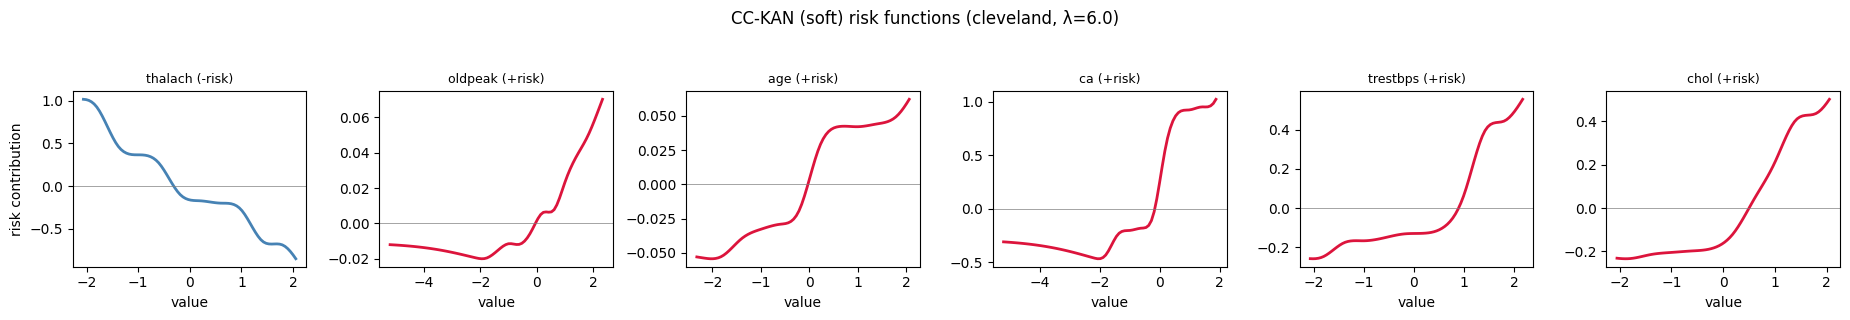

soft per-feature monotonicity: {'thalach': 0.97, 'oldpeak': 0.51, 'age': 0.88, 'ca': 0.54, 'trestbps': 0.95, 'chol': 0.97}


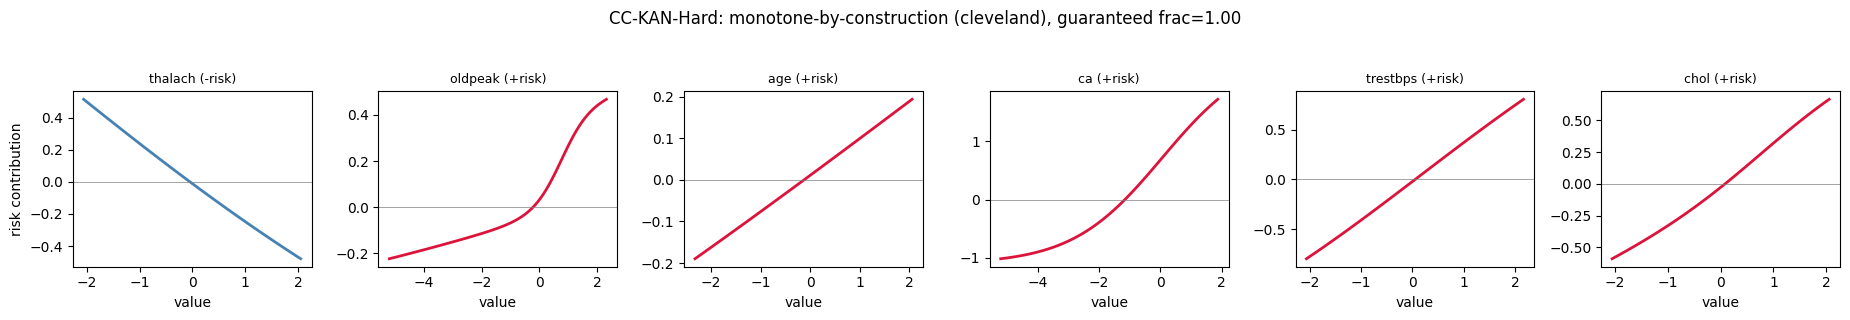

hard guaranteed monotonicity fraction: 1.0


In [8]:
def fig_soft(fn="cleveland",lam_mono=6.0):
    df=load_uci(fn); df,_=drop_high_missing(df)
    feat=[c for c in df.columns if c!="target"]; y=df["target"].values
    cons_names={f:d for f,d in CLIN.items() if f in feat}
    tr,_=train_test_split(np.arange(len(df)),test_size=0.01,stratify=y,random_state=SEED)
    Xtr_df,Xte_df,num=base_clean(df.iloc[tr],df.iloc[tr],feat); Xr,_=robust(Xtr_df,Xte_df,num); Xq,_=quantile(Xr,Xr)
    cons={feat.index(f):d for f,d in cons_names.items()}
    ranges={feat.index(f):np.percentile(Xq[:,feat.index(f)],[2,98]) for f in cons_names}
    torch.manual_seed(SEED); m=train_cckan(Xq,y[tr],cons,ranges,constrained=True,lam_mono=lam_mono,epochs=300)
    show=[s for s in ["thalach","oldpeak","age","ca","trestbps","chol"] if s in cons_names]
    fig,axes=plt.subplots(1,len(show),figsize=(3.1*len(show),3)); monos={}
    for ax,f in zip(axes,show):
        fi=feat.index(f); xs=torch.linspace(ranges[fi][0],ranges[fi][1],80)
        with torch.no_grad(): g=feature_curve(m.layers[0],fi,xs).numpy()
        ax.plot(xs.numpy(),g-g.mean(),lw=2,color="crimson" if CLIN[f]>0 else "steelblue"); ax.axhline(0,color="gray",lw=0.5)
        ax.set_title(f"{f} ({'+risk' if CLIN[f]>0 else '-risk'})",fontsize=9); ax.set_xlabel("value")
        with torch.no_grad(): gg=feature_curve(m.layers[0],fi,torch.linspace(ranges[fi][0],ranges[fi][1],60)).numpy()
        monos[f]=round(float(np.mean((CLIN[f]*np.diff(gg))>=0)),2)
    axes[0].set_ylabel("risk contribution"); plt.suptitle(f"CC-KAN (soft) risk functions ({fn}, λ={lam_mono})",y=1.05)
    plt.tight_layout(); plt.savefig("cckan_functions.png",dpi=130,bbox_inches="tight"); plt.show(); return monos

def fig_hard(fn="cleveland"):
    df=load_uci(fn); df,_=drop_high_missing(df)
    feat=[c for c in df.columns if c!="target"]; y=df["target"].values
    cons_names={f:d for f,d in CLIN.items() if f in feat}
    tr,_=train_test_split(np.arange(len(df)),test_size=0.01,stratify=y,random_state=SEED)
    Xtr_df,Xte_df,num=base_clean(df.iloc[tr],df.iloc[tr],feat); Xr,_=robust(Xtr_df,Xte_df,num); Xq,_=quantile(Xr,Xr)
    cons={feat.index(f):d for f,d in cons_names.items()}
    ranges={feat.index(f):np.percentile(Xq[:,feat.index(f)],[2,98]) for f in cons_names}
    frac,m=hardmono_check(Xq,y[tr],cons,ranges)
    show=[s for s in ["thalach","oldpeak","age","ca","trestbps","chol"] if s in cons_names]
    fig,axes=plt.subplots(1,len(show),figsize=(3.1*len(show),3))
    for ax,f in zip(axes,show):
        fi=feat.index(f); xs=torch.linspace(ranges[fi][0],ranges[fi][1],80)
        with torch.no_grad(): g=m.feature_contrib(xs,fi).numpy()
        ax.plot(xs.numpy(),g-g.mean(),lw=2,color="crimson" if CLIN[f]>0 else "steelblue"); ax.axhline(0,color="gray",lw=0.5)
        ax.set_title(f"{f} ({'+risk' if CLIN[f]>0 else '-risk'})",fontsize=9); ax.set_xlabel("value")
    axes[0].set_ylabel("risk contribution"); plt.suptitle(f"CC-KAN-Hard: monotone-by-construction ({fn}), guaranteed frac={frac:.2f}",y=1.05)
    plt.tight_layout(); plt.savefig("cckan_hard_functions.png",dpi=130,bbox_inches="tight"); plt.show(); return frac

C_soft=fig_soft("cleveland",6.0); print("soft per-feature monotonicity:",C_soft)
C_hard=fig_hard("cleveland"); print("hard guaranteed monotonicity fraction:",round(C_hard,3))


## 8. Experiment D — sanity-checking a famous prior result
**What happens here.** A well-known prior paper reports **>90% accuracy** for a KAN-based model, but on a *different, larger, easier* dataset (a merged 918-row set) and with a more optimistic evaluation setup. This cell checks how much of that number is the *method* versus the *dataset*.

We find that even a **plain logistic regression** already reaches ~0.87 accuracy / ~0.92 AUC on that easier dataset. We also expose a subtle **data artifact**: about 19% of rows record cholesterol as `0` (a placeholder for "missing"), and those rows are overwhelmingly disease cases — a near-giveaway. Fixing it changes accuracy by only ~1 point.

*Analogy:* comparing two students' exam scores is meaningless if they sat *different* exams. A 92% on an easy exam isn't better than 88% on a hard one. This is exactly why our own results use the harder raw cohorts with honest, leak-free scoring.


In [9]:
def experiment_D():
    raw0=pd.read_csv("data/merged918.data")
    raw=pd.get_dummies(raw0.copy(),columns=["Sex","ChestPainType","RestingECG","ExerciseAngina","ST_Slope"],drop_first=True)
    y=raw["HeartDisease"].values; z=(raw0["Cholesterol"]==0)
    leak=dict(n=int(len(y)),pos_rate=round(float(y.mean()),3),chol0_rows=int(z.sum()),
              disease_in_chol0=round(float(raw0.loc[z,"HeartDisease"].mean()),2),
              disease_else=round(float(raw0.loc[~z,"HeartDisease"].mean()),2))
    def run(df):
        X=df.drop(columns="HeartDisease").values.astype(float); skf=StratifiedKFold(5,shuffle=True,random_state=SEED); res={}
        for nm,mk in [("LogReg",lambda:LogisticRegression(max_iter=2000)),("RandomForest",lambda:RandomForestClassifier(n_estimators=300,random_state=SEED))]:
            a=[];u=[]
            for tr,te in skf.split(X,y):
                imp=SimpleImputer(strategy="median").fit(X[tr]); Xt,Xe=imp.transform(X[tr]),imp.transform(X[te])
                s=StandardScaler().fit(Xt); Xt,Xe=s.transform(Xt),s.transform(Xe)
                m=mk().fit(Xt,y[tr]); p=m.predict_proba(Xe)[:,1]
                a.append(accuracy_score(y[te],(p>=.5).astype(int))); u.append(roc_auc_score(y[te],p))
            res[nm]=(round(np.mean(a),3),round(np.mean(u),3))
        return res
    with_leak=run(raw.copy())
    fix=raw.copy(); fix.loc[(raw0["Cholesterol"]==0).values,"Cholesterol"]=np.nan
    fixed=run(fix)
    return leak,with_leak,fixed
D_leak,D_with,D_fixed=experiment_D()
print("===== EXPERIMENT D ====="); print("leak:",D_leak); print("WITH chol=0:",D_with); print("chol=0 fixed:",D_fixed)


===== EXPERIMENT D =====
leak: {'n': 918, 'pos_rate': 0.553, 'chol0_rows': 172, 'disease_in_chol0': 0.88, 'disease_else': 0.48}
WITH chol=0: {'LogReg': (np.float64(0.867), np.float64(0.925)), 'RandomForest': (np.float64(0.869), np.float64(0.926))}
chol=0 fixed: {'LogReg': (np.float64(0.858), np.float64(0.921)), 'RandomForest': (np.float64(0.875), np.float64(0.924))}


## 9. Experiment E — where to draw the decision line (threshold)
**What happens here.** A model outputs a *probability*; turning it into a yes/no needs a cutoff (default 0.5). Under class imbalance, 0.5 is often not where accuracy is highest, which is one reason a model can have high AUC (good ranking) but modest accuracy at 0.5.

Here we pick the cutoff that maximizes *balanced accuracy* **using the training patients only** (never the test patients — no cheating), then apply it to the test set.

*Analogy:* choosing the pass/fail line for an exam. Move it and you trade off catching more true cases against raising false alarms. In our runs the default 0.5 was already near-optimal, so this mostly confirms the earlier numbers.


In [10]:
# choose threshold on TRAIN (balanced accuracy), apply to TEST; report acc@0.5 vs acc@opt
def best_thr(ytr,ptr):
    best,bv=0.5,-1
    for t in np.linspace(0.2,0.8,25):
        v=balanced_accuracy_score(ytr,(ptr>=t).astype(int))
        if v>bv: bv,best=v,t
    return best
def experiment_E(name,fn):
    df=load_uci(fn); df,_=drop_high_missing(df)
    feat=[c for c in df.columns if c!="target"]; y=df["target"].values
    cons_names={f:d for f,d in CLIN.items() if f in feat}
    skf=StratifiedKFold(5,shuffle=True,random_state=SEED); a05=[];aopt=[];aucs=[]
    for tr,te in skf.split(df[feat],y):
        Xtr_df,Xte_df,num=base_clean(df.iloc[tr],df.iloc[te],feat); ytr,yte=y[tr],y[te]
        Xr_tr,Xr_te=robust(Xtr_df,Xte_df,num); Xq_tr,Xq_te=quantile(Xr_tr,Xr_te)
        cons={feat.index(f):d for f,d in cons_names.items()}
        p_te,p_tr=ens_hardmono(Xq_tr,ytr,Xq_te,cons,return_train=True)
        t=best_thr(ytr,p_tr)
        a05.append(accuracy_score(yte,(p_te>=0.5).astype(int)))
        aopt.append(accuracy_score(yte,(p_te>=t).astype(int)))
        aucs.append(roc_auc_score(yte,p_te))
    return dict(cohort=name,acc_at_0p5=round(np.mean(a05),4),acc_at_opt=round(np.mean(aopt),4),auc=round(np.mean(aucs),4))
t0=time.time(); E=[]
for name,fn in [("Cleveland","cleveland"),("Hungarian","hungarian")]:
    print(f"Experiment E: {name} ..."); E.append(experiment_E(name,fn)); print(f"  done ({time.time()-t0:.0f}s)")
E_df=pd.DataFrame(E)
print("\n===== EXPERIMENT E (CC-KAN-Hard) =====")
print(E_df.to_string(index=False))
print("(acc_at_opt uses a threshold chosen on TRAIN only -> leak-free)")


Experiment E: Cleveland ...
  done (49s)
Experiment E: Hungarian ...
  done (89s)

===== EXPERIMENT E (CC-KAN-Hard) =====
   cohort  acc_at_0p5  acc_at_opt    auc
Cleveland      0.8449      0.8350 0.9166
Hungarian      0.8301      0.8098 0.8842
(acc_at_opt uses a threshold chosen on TRAIN only -> leak-free)


## 10. Experiment F — does it work in a *different* hospital? (external validation)
**What happens here.** The strongest test of a clinical model: train it entirely on **one** cohort (say Cleveland) and test it on a **completely unseen** other cohort (Hungarian), and vice-versa. All preprocessing is fit on the training cohort only.

*Analogy:* a model built from one city's patients being used, untouched, on another city's patients — the real deployment scenario. Most heart-disease papers never do this. We check whether our interpretable, constrained model still holds up out-of-distribution (it transfers competitively with the black-box SVM while remaining fully explainable).


In [11]:
def experiment_F():
    results=[]
    pairs=[("Cleveland","cleveland","Hungarian","hungarian"),
           ("Hungarian","hungarian","Cleveland","cleveland")]
    for tr_name,tr_fn,te_name,te_fn in pairs:
        da=load_uci(tr_fn); da,_=drop_high_missing(da)
        db=load_uci(te_fn); db,_=drop_high_missing(db)
        feat=[c for c in da.columns if c in db.columns and c!="target"]  # common features
        ytr=da["target"].values; yte=db["target"].values
        Xtr_df,Xte_df,num=base_clean(da,db,feat)            # fit on TRAIN cohort only
        Xr_tr,Xr_te=robust(Xtr_df,Xte_df,num); Xq_tr,Xq_te=quantile(Xr_tr,Xr_te)
        cons_names={f:d for f,d in CLIN.items() if f in feat}
        cons={feat.index(f):d for f,d in cons_names.items()}
        # SVM (black-box baseline)
        s=SVC(kernel="rbf",probability=True,class_weight="balanced",random_state=SEED).fit(Xr_tr,ytr)
        p_svm=s.predict_proba(Xr_te)[:,1]
        # Additive-KAN unconstrained
        p_add,_=ens_cckan(Xq_tr,ytr,Xq_te,cons,{feat.index(f):np.percentile(Xq_tr[:,feat.index(f)],[2,98]) for f in cons_names},constrained=False)
        # CC-KAN-Hard (constrained)
        p_hard=ens_hardmono(Xq_tr,ytr,Xq_te,cons)
        for mname,p in [("SVM",p_svm),("Additive-KAN (unconstrained)",p_add),("CC-KAN-Hard (constrained)",p_hard)]:
            results.append(dict(direction=f"{tr_name}->{te_name}",model=mname,
                                auc=round(roc_auc_score(yte,p),4),
                                acc=round(accuracy_score(yte,(p>=0.5).astype(int)),4),
                                recall=round(recall_score(yte,(p>=0.5).astype(int),zero_division=0),4)))
    return pd.DataFrame(results)

t0=time.time(); F_df=experiment_F(); print(f"Experiment F done ({time.time()-t0:.0f}s)")
print("\n===== EXPERIMENT F: external cross-cohort validation =====")
print(F_df.to_string(index=False))


Experiment F done (22s)

===== EXPERIMENT F: external cross-cohort validation =====
           direction                        model    auc    acc  recall
Cleveland->Hungarian                          SVM 0.8881 0.8333  0.7642
Cleveland->Hungarian Additive-KAN (unconstrained) 0.8601 0.8061  0.8585
Cleveland->Hungarian    CC-KAN-Hard (constrained) 0.8881 0.8299  0.7264
Hungarian->Cleveland                          SVM 0.8484 0.7921  0.7338
Hungarian->Cleveland Additive-KAN (unconstrained) 0.8405 0.7690  0.6259
Hungarian->Cleveland    CC-KAN-Hard (constrained) 0.8577 0.7591  0.6978


## 11. Experiment G — which ingredient actually matters? (ablation)
**What happens here.** We take our best model apart, removing one component at a time — the clinical constraint, the ensemble, or the quantile transform — and measure the drop.

*Analogy:* cooking a dish, then remaking it with one ingredient removed each time to learn which ingredient truly matters. This tells the honest story: the clinical constraint buys *guaranteed interpretability at essentially no accuracy cost* (and a small gain on Hungarian) — not a universal accuracy boost. Reporting this plainly is what makes the paper credible.


In [12]:
def experiment_G(name,fn):
    df=load_uci(fn); df,_=drop_high_missing(df)
    feat=[c for c in df.columns if c!="target"]; y=df["target"].values
    cons_names={f:d for f,d in CLIN.items() if f in feat}
    skf=StratifiedKFold(5,shuffle=True,random_state=SEED)
    configs=["Full (quantile+constraint+ensemble)","(-) clinical constraint","(-) ensemble","(-) quantile (use robust)"]
    R={c:{"auc":[],"acc":[]} for c in configs}
    for tr,te in skf.split(df[feat],y):
        Xtr_df,Xte_df,num=base_clean(df.iloc[tr],df.iloc[te],feat); ytr,yte=y[tr],y[te]
        Xr_tr,Xr_te=robust(Xtr_df,Xte_df,num); Xq_tr,Xq_te=quantile(Xr_tr,Xr_te)
        cons={feat.index(f):d for f,d in cons_names.items()}
        pF =ens_hardmono(Xq_tr,ytr,Xq_te,cons)          # full
        pNC=ens_hardmono(Xq_tr,ytr,Xq_te,{})            # no constraint (all features free)
        torch.manual_seed(SEED); m=train_hardmono(Xq_tr,ytr,cons); pNE=predict_hardmono(m,Xq_te)  # no ensemble
        pNQ=ens_hardmono(Xr_tr,ytr,Xr_te,cons)          # no quantile (robust input)
        for cfg,p in zip(configs,[pF,pNC,pNE,pNQ]):
            R[cfg]["auc"].append(roc_auc_score(yte,p)); R[cfg]["acc"].append(accuracy_score(yte,(p>=0.5).astype(int)))
    return [dict(cohort=name,config=c,auc=round(np.mean(d["auc"]),4),acc=round(np.mean(d["acc"]),4)) for c,d in R.items()]

t0=time.time(); G_rows=[]
for name,fn in [("Cleveland","cleveland"),("Hungarian","hungarian")]:
    print(f"Experiment G: {name} ..."); G_rows+=experiment_G(name,fn); print(f"  done ({time.time()-t0:.0f}s)")
G_df=pd.DataFrame(G_rows)
print("\n===== EXPERIMENT G: ablation (AUC) =====")
print(G_df.pivot(index="config",columns="cohort",values="auc")
      .reindex(["Full (quantile+constraint+ensemble)","(-) clinical constraint","(-) ensemble","(-) quantile (use robust)"]).to_string())


Experiment G: Cleveland ...
  done (147s)
Experiment G: Hungarian ...
  done (269s)

===== EXPERIMENT G: ablation (AUC) =====
cohort                               Cleveland  Hungarian
config                                                   
Full (quantile+constraint+ensemble)     0.9166     0.8842
(-) clinical constraint                 0.9164     0.8691
(-) ensemble                            0.9168     0.8825
(-) quantile (use robust)               0.9138     0.8808


## 12. Final results — copy this block back
**What happens here.** This gathers every result into one printout. Copy everything under `=== RESULTS TO SEND BACK ===`, and also download the two figures (`cckan_functions.png`, `cckan_hard_functions.png`) from the file panel on the left.

Remember the honest framing these numbers support: our model is **competitive with the best black boxes on AUC while being fully, provably interpretable** — *not* "beats everything," and *not* "statistically significantly better" (only 5 folds). That calibrated claim is exactly what makes the work defensible.


In [13]:
print("="*72); print("=== RESULTS TO SEND BACK ==="); print("="*72)
print("\n[A] MAIN COMPARISON (5-fold CV)"); print(A_df.to_string(index=False))
print("\nWilcoxon vs SVM (per-fold AUC):",json.dumps(A_stats))
print("\n[B] CONSTRAINT FRONTIER (auc, acc, monotonicity)"); print(json.dumps(B,indent=2))
print("\n[C] INTERPRETABILITY"); print("soft per-feature monotonicity:",json.dumps(C_soft)); print("hard guaranteed monotonicity:",round(C_hard,3))
print("\n[D] KACQ-DCNN SETTING (918-row)"); print("leak:",json.dumps(D_leak)); print("with_chol0:",json.dumps(D_with)); print("chol0_fixed:",json.dumps(D_fixed))
print("\n[E] THRESHOLD OPTIMIZATION (CC-KAN-Hard)"); print(E_df.to_string(index=False))
print("\n[F] EXTERNAL CROSS-COHORT VALIDATION"); print(F_df.to_string(index=False))
print("\n[G] ABLATION (AUC)")
print(G_df.pivot(index="config",columns="cohort",values="auc").reindex(["Full (quantile+constraint+ensemble)","(-) clinical constraint","(-) ensemble","(-) quantile (use robust)"]).to_string())
print("\n(Also download cckan_functions.png and cckan_hard_functions.png)")
print("="*72)


=== RESULTS TO SEND BACK ===

[A] MAIN COMPARISON (5-fold CV)
   cohort         model    acc  acc_std    auc  recall     f1
Cleveland    ExtraTrees 0.8415   0.0274 0.9179  0.8127 0.8246
Cleveland           SVM 0.8382   0.0288 0.8958  0.7984 0.8185
Cleveland  RandomForest 0.8450   0.0334 0.9098  0.7915 0.8245
Cleveland           ANN 0.7818   0.0522 0.8359  0.7765 0.7652
Cleveland KAN(baseline) 0.7984   0.0471 0.8741  0.7693 0.7766
Cleveland  KAN-Improved 0.8185   0.0346 0.8952  0.7913 0.8010
Cleveland  Additive-KAN 0.7986   0.0221 0.8889  0.7698 0.7782
Cleveland        CC-KAN 0.8218   0.0281 0.8944  0.7987 0.8043
Cleveland   CC-KAN-Hard 0.8449   0.0369 0.9166  0.8130 0.8274
Hungarian    ExtraTrees 0.7961   0.0436 0.8768  0.6420 0.6960
Hungarian           SVM 0.8302   0.0583 0.8819  0.7264 0.7536
Hungarian  RandomForest 0.7960   0.0438 0.8780  0.6316 0.6904
Hungarian           ANN 0.7755   0.0424 0.8152  0.6407 0.6696
Hungarian KAN(baseline) 0.8162   0.0554 0.8638  0.7351 0.7441
Hungaria

13. Generate all paper figures
What happens here. Every experiment above stored its numbers in memory (A_df, B, F_df, G_df, …). This final section simply plots those stored results — it does not re-run any experiment, so it is fast. It produces the six figures the manuscript uses:

Constraint frontier (fig_frontier.png) — the key finding: AUC vs. how hard the medical rule is enforced, alongside monotonicity.
EDA (fig_eda.png) — class balance and feature–target correlations (note the signs match the clinical directions).
Model comparison (fig_main_comparison.png) — AUC of every model on both cohorts.
External cross-cohort (fig_cross_cohort.png) — train-on-one-hospital, test-on-the-other.
Ablation (fig_ablation.png) — effect of removing each component.
Pipeline diagram (fig_pipeline.png) — the architecture at a glance.
The two learned-function figures (cckan_functions.png, cckan_hard_functions.png) were already saved back in Experiment C. Download all of them from the file panel on the left. Analogy: the experiments did the cooking; this cell just plates the dishes for presentation.

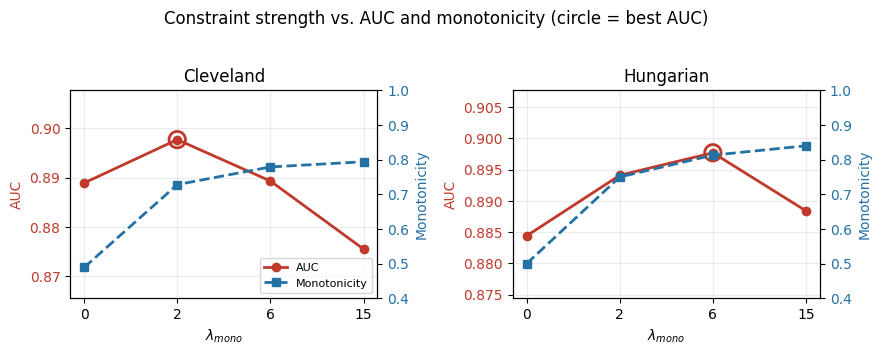

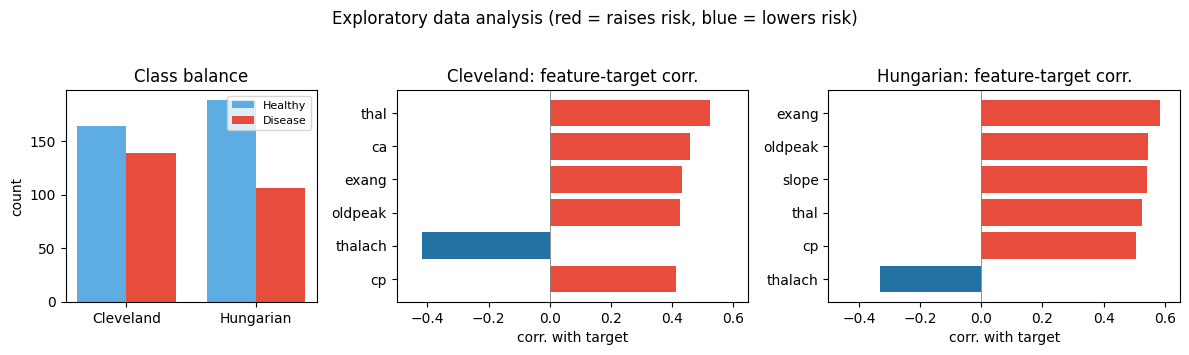

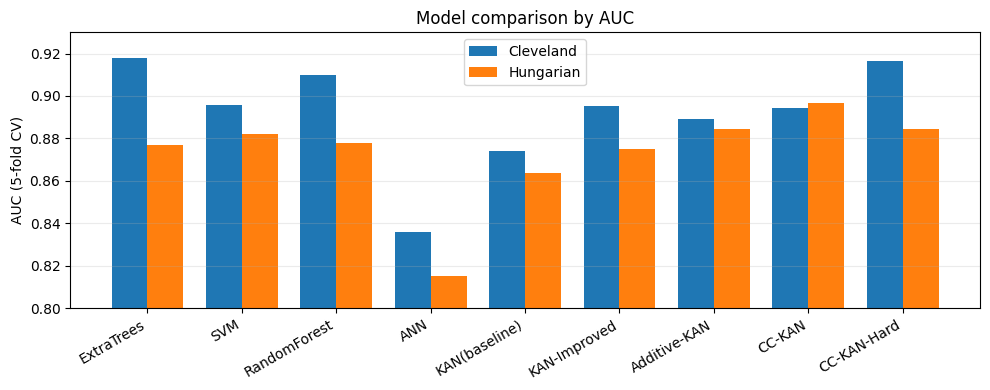

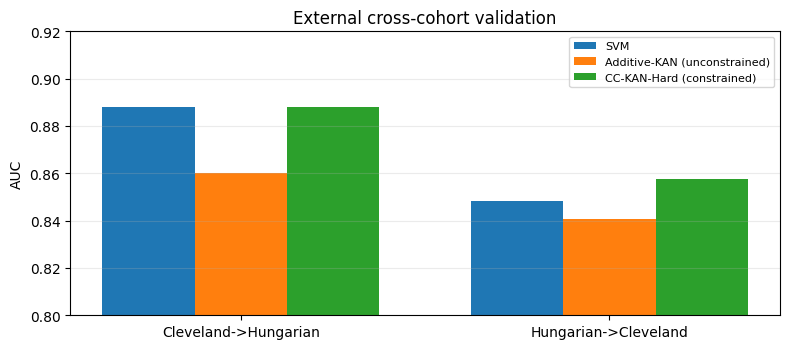

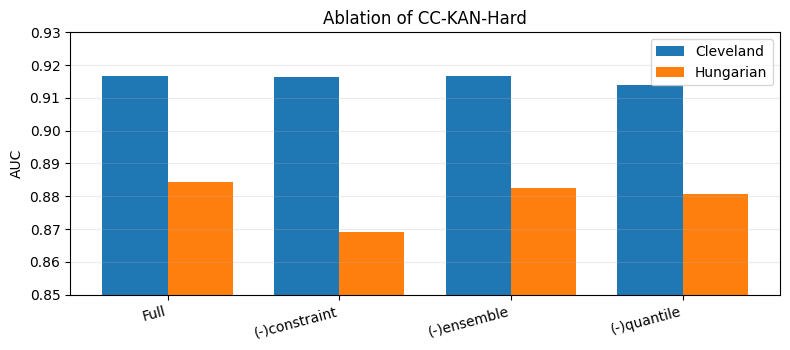

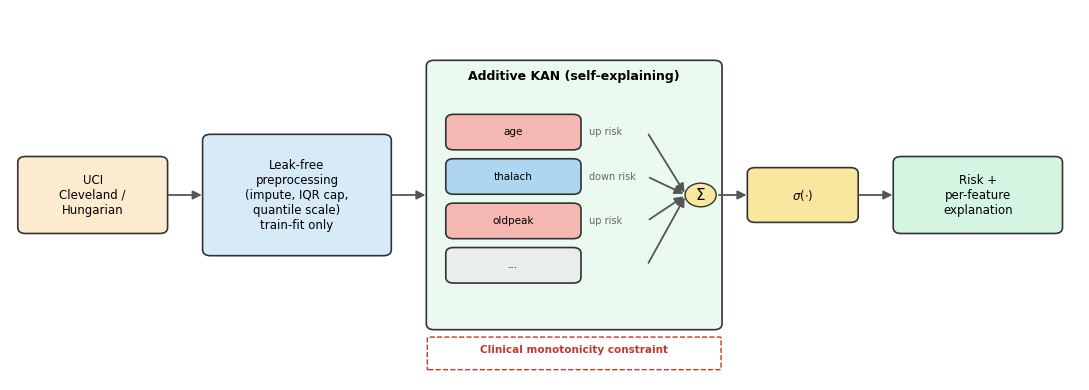

Saved: fig_frontier, fig_eda, fig_main_comparison, fig_cross_cohort, fig_ablation, fig_pipeline (.png)
Plus (from Experiment C): cckan_functions.png, cckan_hard_functions.png


In [14]:
# ============================================================
# Generate ALL paper figures from results already in memory.
# (No experiments are re-run; we only plot A_df, B, F_df, G_df, etc.)
# Saved PNGs appear in the file panel on the left for download.
# ============================================================
import numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

COH = ["Cleveland","Hungarian"]

# ---- FIG 1: constraint frontier (from Experiment B) ----
fig,axes=plt.subplots(1,2,figsize=(9,3.4))
for ax,name in zip(axes,COH):
    lams=sorted(B[name].keys())
    auc=[B[name][l][0] for l in lams]; mono=[B[name][l][2] for l in lams]
    x=np.arange(len(lams))
    l1=ax.plot(x,auc,'o-',color="#c0392b",lw=2)[0]
    ax.set_ylim(min(auc)-0.01,max(auc)+0.01); ax.set_ylabel("AUC",color="#c0392b")
    ax.tick_params(axis='y',labelcolor="#c0392b"); ax.set_xticks(x); ax.set_xticklabels([int(l) for l in lams])
    ax.set_xlabel(r"$\lambda_{mono}$"); ax.grid(alpha=0.25)
    ax2=ax.twinx()
    l2=ax2.plot(x,mono,'s--',color="#2471a3",lw=2)[0]
    ax2.set_ylim(0.4,1.0); ax2.set_ylabel("Monotonicity",color="#2471a3"); ax2.tick_params(axis='y',labelcolor="#2471a3")
    bi=int(np.argmax(auc)); ax.scatter([bi],[auc[bi]],s=140,facecolors='none',edgecolors="#c0392b",lw=2,zorder=5)
    ax.set_title(name)
axes[0].legend([l1,l2],["AUC","Monotonicity"],loc="lower right",fontsize=8)
plt.suptitle("Constraint strength vs. AUC and monotonicity (circle = best AUC)",y=1.03)
plt.tight_layout(); plt.savefig("fig_frontier.png",dpi=200,bbox_inches="tight"); plt.show()

# ---- FIG 2: EDA (class balance + feature-target correlations) ----
fig,axes=plt.subplots(1,3,figsize=(12,3.4),gridspec_kw={'width_ratios':[1,1.4,1.4]})
bal={}; corr={}
for fn,name in [("cleveland","Cleveland"),("hungarian","Hungarian")]:
    d=load_uci(fn); y=d["target"]
    bal[name]=(int((y==0).sum()),int(y.sum()))
    c=d.drop(columns="target").apply(lambda col: col.corr(y)).dropna()
    corr[name]=c.reindex(c.abs().sort_values(ascending=False).index).head(6).round(3).to_dict()
ax=axes[0]; x=np.arange(len(COH)); w=0.38
ax.bar(x-w/2,[bal[n][0] for n in COH],w,label="Healthy",color="#5dade2")
ax.bar(x+w/2,[bal[n][1] for n in COH],w,label="Disease",color="#e74c3c")
ax.set_xticks(x); ax.set_xticklabels(COH); ax.set_ylabel("count"); ax.set_title("Class balance"); ax.legend(fontsize=8)
for ax,name in zip(axes[1:],COH):
    feats=list(corr[name].keys()); vals=[corr[name][f] for f in feats]
    ax.barh(range(len(feats)),vals,color=["#e74c3c" if v>0 else "#2471a3" for v in vals])
    ax.set_yticks(range(len(feats))); ax.set_yticklabels(feats); ax.invert_yaxis()
    ax.axvline(0,color="gray",lw=0.6); ax.set_xlim(-0.5,0.65); ax.set_xlabel("corr. with target"); ax.set_title(f"{name}: feature-target corr.")
plt.suptitle("Exploratory data analysis (red = raises risk, blue = lowers risk)",y=1.03)
plt.tight_layout(); plt.savefig("fig_eda.png",dpi=200,bbox_inches="tight"); plt.show()

# ---- FIG 3: main comparison, AUC per model per cohort (from A_df) ----
order=["ExtraTrees","SVM","RandomForest","ANN","KAN(baseline)","KAN-Improved","Additive-KAN","CC-KAN","CC-KAN-Hard"]
piv=A_df.pivot(index="model",columns="cohort",values="auc").reindex(order)
fig,ax=plt.subplots(figsize=(10,4)); x=np.arange(len(order)); w=0.38
for k,name in enumerate(COH):
    ax.bar(x+(k-0.5)*w, piv[name].values, w, label=name)
ax.set_xticks(x); ax.set_xticklabels(order,rotation=30,ha="right"); ax.set_ylim(0.80,0.93)
ax.set_ylabel("AUC (5-fold CV)"); ax.set_title("Model comparison by AUC"); ax.legend(); ax.grid(axis="y",alpha=0.25)
plt.tight_layout(); plt.savefig("fig_main_comparison.png",dpi=200,bbox_inches="tight"); plt.show()

# ---- FIG 4: external cross-cohort (from F_df) ----
fig,ax=plt.subplots(figsize=(8,3.6))
dirs=list(dict.fromkeys(F_df["direction"])); models=list(dict.fromkeys(F_df["model"]))
x=np.arange(len(dirs)); w=0.25
for k,m in enumerate(models):
    vals=[F_df[(F_df.direction==d)&(F_df.model==m)]["auc"].values[0] for d in dirs]
    ax.bar(x+(k-1)*w, vals, w, label=m)
ax.set_xticks(x); ax.set_xticklabels(dirs); ax.set_ylim(0.80,0.92); ax.set_ylabel("AUC")
ax.set_title("External cross-cohort validation"); ax.legend(fontsize=8); ax.grid(axis="y",alpha=0.25)
plt.tight_layout(); plt.savefig("fig_cross_cohort.png",dpi=200,bbox_inches="tight"); plt.show()

# ---- FIG 5: ablation (from G_df) ----
fig,ax=plt.subplots(figsize=(8,3.6))
cfgs=["Full (quantile+constraint+ensemble)","(-) clinical constraint","(-) ensemble","(-) quantile (use robust)"]
short=["Full","(-)constraint","(-)ensemble","(-)quantile"]
x=np.arange(len(cfgs)); w=0.38
for k,name in enumerate(COH):
    vals=[G_df[(G_df.cohort==name)&(G_df.config==c)]["auc"].values[0] for c in cfgs]
    ax.bar(x+(k-0.5)*w, vals, w, label=name)
ax.set_xticks(x); ax.set_xticklabels(short,rotation=15,ha="right"); ax.set_ylim(0.85,0.93)
ax.set_ylabel("AUC"); ax.set_title("Ablation of CC-KAN-Hard"); ax.legend(); ax.grid(axis="y",alpha=0.25)
plt.tight_layout(); plt.savefig("fig_ablation.png",dpi=200,bbox_inches="tight"); plt.show()

# ---- FIG 6: pipeline schematic (conceptual) ----
fig,ax=plt.subplots(figsize=(11,4.0)); ax.set_xlim(0,11); ax.set_ylim(0,5); ax.axis("off")
def box(x,y,w,h,t,fc,fs=8.5):
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle="round,pad=0.02,rounding_size=0.08",fc=fc,ec="#333",lw=1.2))
    ax.text(x+w/2,y+h/2,t,ha="center",va="center",fontsize=fs)
def arr(x1,y1,x2,y2):
    ax.add_patch(FancyArrowPatch((x1,y1),(x2,y2),arrowstyle="-|>",mutation_scale=13,lw=1.3,color="#555"))
box(0.1,2.0,1.5,1.0,"UCI\nCleveland /\nHungarian","#fdebd0"); arr(1.6,2.5,2.0,2.5)
box(2.0,1.7,1.9,1.6,"Leak-free\npreprocessing\n(impute, IQR cap,\nquantile scale)\ntrain-fit only","#d6eaf8"); arr(3.9,2.5,4.3,2.5)
box(4.3,0.7,3.0,3.6,"","#eafaf1"); ax.text(5.8,4.05,"Additive KAN (self-explaining)",ha="center",fontsize=9,weight="bold")
for (f,s),yv in zip([("age","+"),("thalach","-"),("oldpeak","+"),("...","")],[3.35,2.75,2.15,1.55]):
    col="#f5b7b1" if s=="+" else ("#aed6f1" if s=="-" else "#eaeded")
    box(4.5,yv-0.22,1.35,0.44,f,col,fs=7.5)
    ax.text(5.95,yv,("up risk" if s=="+" else ("down risk" if s=="-" else "")),va="center",fontsize=7,color="#666"); arr(6.55,yv,6.95,2.5)
ax.add_patch(plt.Circle((7.1,2.5),0.16,fc="#f9e79f",ec="#333")); ax.text(7.1,2.5,r"$\Sigma$",ha="center",va="center",fontsize=11); arr(7.26,2.5,7.6,2.5)
box(7.6,2.15,1.1,0.7,r"$\sigma(\cdot)$","#f9e79f"); arr(8.7,2.5,9.1,2.5)
box(9.1,2.0,1.7,1.0,"Risk +\nper-feature\nexplanation","#d5f5e3")
ax.add_patch(FancyBboxPatch((4.3,0.15),3.0,0.42,boxstyle="round,pad=0.01",fc="none",ec="#c0392b",lw=1.0,ls="--"))
ax.text(5.8,0.36,"Clinical monotonicity constraint",ha="center",fontsize=7.5,color="#c0392b",weight="bold")
plt.tight_layout(); plt.savefig("fig_pipeline.png",dpi=200,bbox_inches="tight"); plt.show()

print("Saved: fig_frontier, fig_eda, fig_main_comparison, fig_cross_cohort, fig_ablation, fig_pipeline (.png)")
print("Plus (from Experiment C): cckan_functions.png, cckan_hard_functions.png")